In [219]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, accuracy_score, roc_curve, auc
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from utils import download_data, create_features

# intialize state for predictability
RANDOM_STATE = 55

----------------------
1. Download Stock Data
----------------------

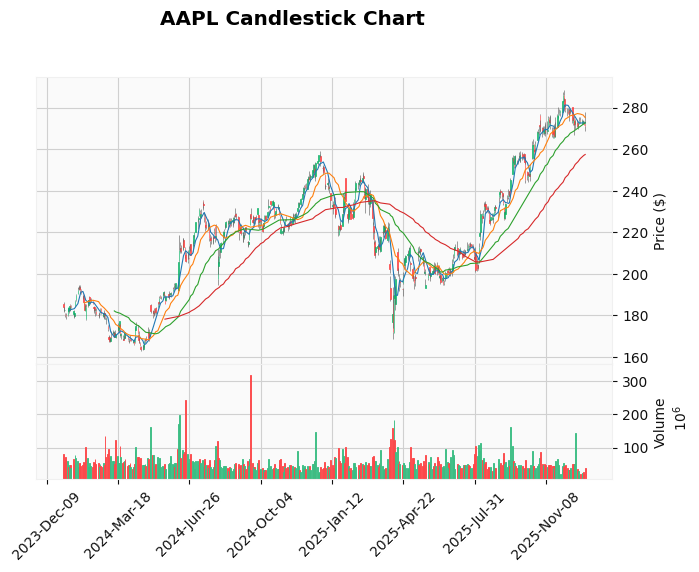

In [282]:
ticker = "AAPL"
ticker_data = yf.Ticker(ticker)
stock_data = ticker_data.history(start="2024-01-01",end=None,interval='1d')
# Plot the candlestick chart
mpf.plot(stock_data,
         type='candle',
         mav=(7,21,50,100),
         show_nontrading=True,
         volume=True,  # Add volume bars
         style='yahoo', # Use a built-in style
         title=f'{ticker} Candlestick Chart',
         ylabel='Price ($)',
         ylabel_lower='Volume'
)

In [284]:
returns = stock_data["Close"].pct_change()
print(f"Percent Gain: {round(returns.sum()*100,2)}%")
print(f"Annualized Gain: {round(stock_data["Close"].pct_change().sum()*100/(len(returns)/261),2)}%")

Percent Gain: 46.43%
Annualized Gain: 24.09%


----------------------
2. Prepare data
----------------------

In [287]:
df = download_data(ticker='AAPL', start='2024-01-01', end=None, save_csv=None)
df = create_features(df)
features = ["Close", "MA5", "MA20", "Return", "Volume"]
X = df[features]
y = (df['Return'].shift(-1) > 0).astype(int) # buy signal

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=False)
print(f'Data features X.shape: {X.shape}')
print(f'Data labels y.shape: {y.shape}')

/Users/jessehernandez/ML_Learning/Projects/stock-price-predictor/src/utils.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)


Data features X.shape: (483, 5)
Data labels y.shape: (483,)


----------------------
3. Building the model
----------------------

In [288]:
min_samples_split_list = [2,10, 30, 50, 100, 200]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

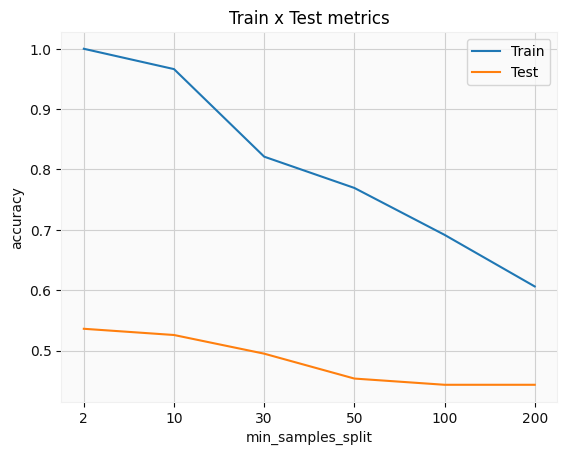

In [289]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list) 
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

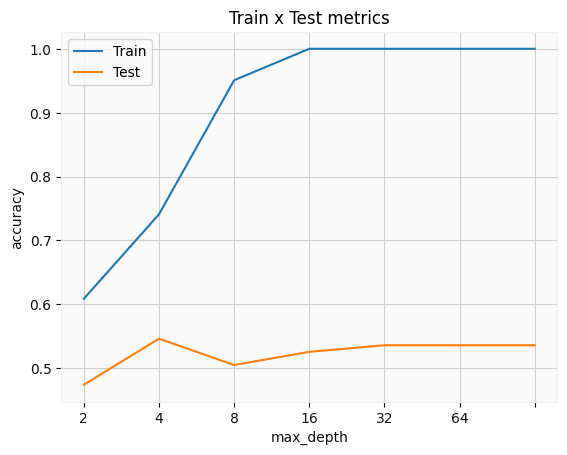

In [290]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth = max_depth,
                                  random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

In [291]:
accuracy_list_train = {}
accuracy_list_test = {}
for max_depth in max_depth_list:
    for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
        model = RandomForestClassifier(min_samples_split = min_samples_split,
                                      max_depth = max_depth,
                                      random_state = RANDOM_STATE).fit(X_train,y_train) 
        predictions_train = model.predict(X_train) ## The predicted values for the train dataset
        predictions_test = model.predict(X_test) ## The predicted values for the test dataset
        accuracy_train = accuracy_score(predictions_train,y_train)
        accuracy_test = accuracy_score(predictions_test,y_test)
        accuracy_list_train.setdefault(max_depth,[]).append(accuracy_train)
        accuracy_list_test.setdefault(max_depth,[]).append(accuracy_test)

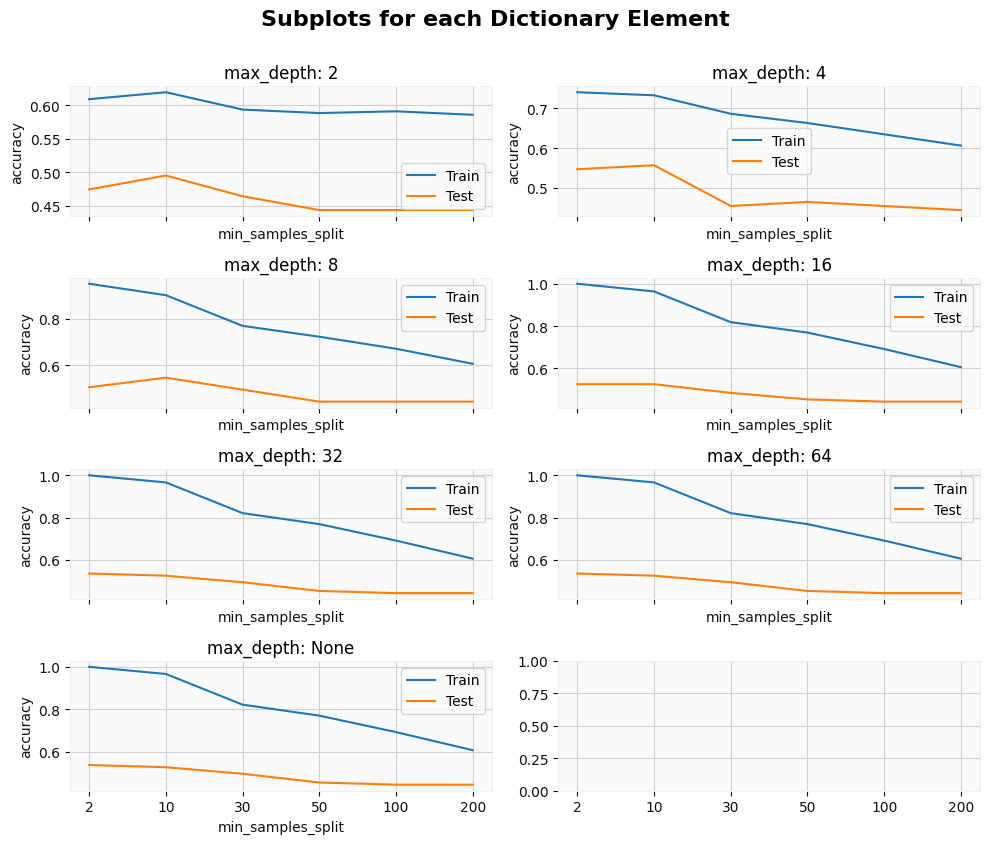

In [292]:
# Determine the number of rows and columns for the subplot grid
num_items = len(accuracy_list_train)
rows = int(np.ceil(num_items / 2)) # e.g., 2 rows for 4 items
cols = 2 # e.g., 2 columns

# Create the figure and a 2D array of axes (subplots)
# sharex/sharey helps keep the axes consistent
fig, axes = plt.subplots(rows, cols, figsize=(10, 8), sharex=True, sharey=False)

# Flatten the axes array to easily iterate over it in a single loop
# This changes the 2x2 array into a 1D array of 4 axes objects
axes = axes.ravel()

plt.setp(axes, xticks=range(len(min_samples_split_list )), xticklabels=min_samples_split_list)

# Iterate through the dictionary items and the axes array simultaneously
for i, (key, value) in enumerate(accuracy_list_train.items()):
    ax = axes[i] # Select the current axis
    ax.plot(value, label='Train') # Plot the data on the axis
    ax.plot(accuracy_list_test[key], label='Test')
    ax.set_title(f'max_depth: {key}')
    #ax.set_title(key) # Set the title from the dictionary key
    ax.set_xlabel('min_samples_split')
    ax.set_ylabel('accuracy')
    ax.legend()
# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# Add a super title for the entire figure
plt.suptitle('Subplots for each Dictionary Element', y=1.05, fontsize=16)


# Display the plot
plt.show()

In [293]:
accuracy_list_train = {}
accuracy_list_test = {}
for min_samples_split in min_samples_split_list:
    for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
        model = RandomForestClassifier(min_samples_split = min_samples_split,
                                      max_depth = max_depth,
                                      random_state = RANDOM_STATE).fit(X_train,y_train) 
        predictions_train = model.predict(X_train) ## The predicted values for the train dataset
        predictions_test = model.predict(X_test) ## The predicted values for the test dataset
        accuracy_train = accuracy_score(predictions_train,y_train)
        accuracy_test = accuracy_score(predictions_test,y_test)
        accuracy_list_train.setdefault(min_samples_split,[]).append(accuracy_train)
        accuracy_list_test.setdefault(min_samples_split,[]).append(accuracy_test)


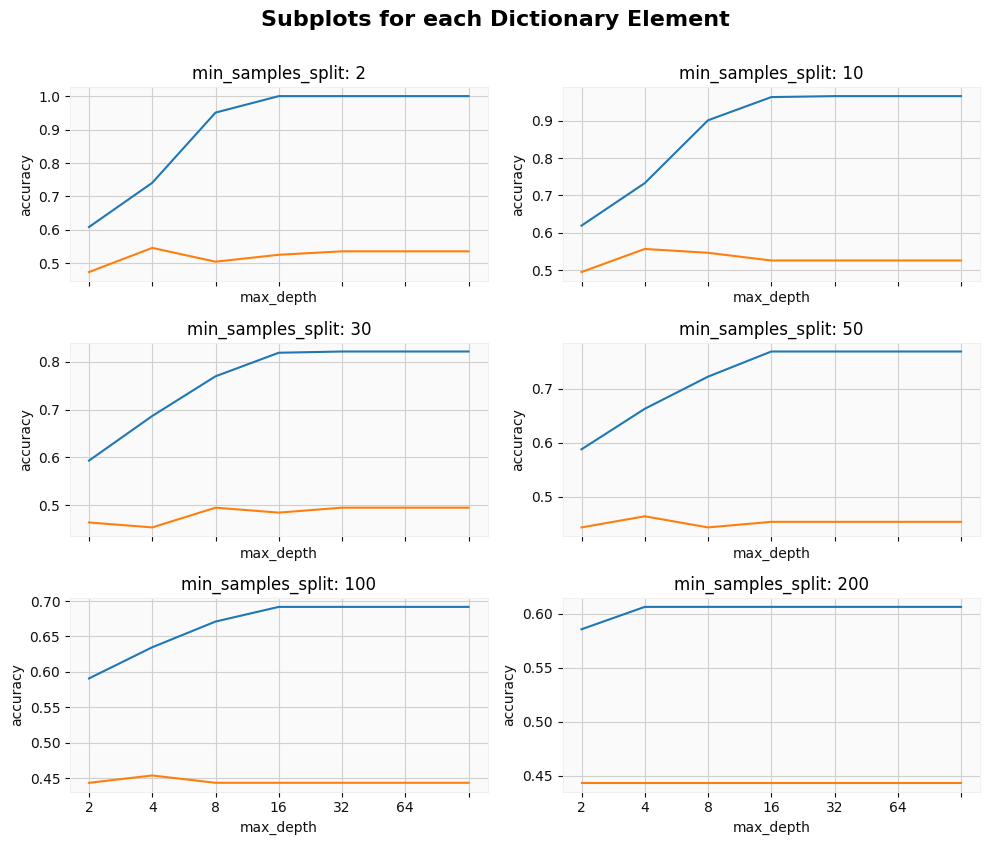

In [294]:
# Determine the number of rows and columns for the subplot grid
num_items = len(accuracy_list_train)
rows = int(np.ceil(num_items / 2)) # e.g., 2 rows for 4 items
cols = 2 # e.g., 2 columns

# Create the figure and a 2D array of axes (subplots)
# sharex/sharey helps keep the axes consistent
fig, axes = plt.subplots(rows, cols, figsize=(10, 8), sharex=True, sharey=False)

# Flatten the axes array to easily iterate over it in a single loop
# This changes the 2x2 array into a 1D array of 4 axes objects
axes = axes.ravel()

plt.setp(axes, xticks=range(len(max_depth_list )), xticklabels=max_depth_list)

# Iterate through the dictionary items and the axes array simultaneously
for i, (key, value) in enumerate(accuracy_list_train.items()):
    ax = axes[i] # Select the current axis
    ax.plot(value) # Plot the data on the axis
    ax.plot(accuracy_list_test[key])
    ax.set_title(f'min_samples_split: {key}')
    #ax.set_title(key) # Set the title from the dictionary key
    ax.set_xlabel('max_depth')
    ax.set_ylabel('accuracy')

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# Add a super title for the entire figure
plt.suptitle('Subplots for each Dictionary Element', y=1.05, fontsize=16)

# Display the plot
plt.show()

In [295]:
model = RandomForestClassifier(n_estimators = 100,
                               min_samples_split = 10,
                               max_depth = 4,
                               random_state = RANDOM_STATE).fit(X_train,y_train)

preds = model.predict(X_test)
error = accuracy_score(y_test, preds)

print(f"Mean Absolute Error: {round(error, 2)}")

Mean Absolute Error: 0.56


In [296]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.7332
Metrics test:
	Accuracy score: 0.5567


----------------------
4. Visualize prediction vs actual
----------------------

In [297]:
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

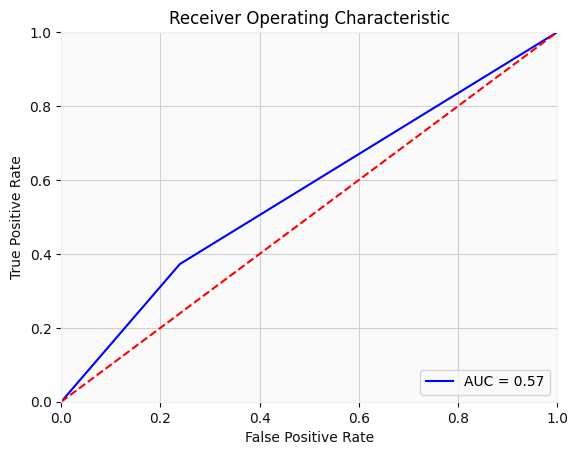

In [298]:
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

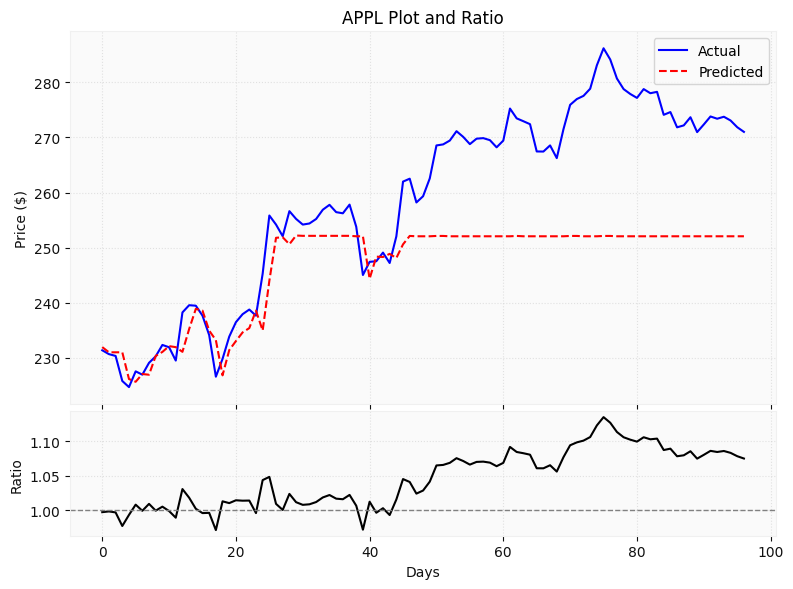

In [118]:
ratio = y_test / preds

# 2. Create figure and subplots
# Use gridspec_kw to control the relative height of the subplots
fig, (ax_main, ax_ratio) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    gridspec_kw={'height_ratios': [3, 1]}, # Main plot is 3x taller than the ratio plot
    figsize=(8, 6)
)

# 3. Plot the main data
ax_main.plot(y_test, label='Actual', color='blue')
ax_main.plot(preds, label='Predicted', color='red', linestyle='--')
ax_main.set_ylabel('Price ($)')
ax_main.set_title('APPL Plot and Ratio')
ax_main.legend()
ax_main.grid(True, linestyle=':', alpha=0.6)

# 4. Plot the ratio
ax_ratio.plot(ratio, color='black', linestyle='-')
ax_ratio.set_xlabel('Days')
ax_ratio.set_ylabel('Ratio')
#ax_ratio.set_ylim(0.9, 1.2) # Set appropriate limits for the ratio plot
ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1) # Add a line at y=1 for reference
ax_ratio.grid(True, linestyle=':', alpha=0.6)

# 5. Adjust layout and display
plt.tight_layout()
# Adjust space between subplots to remove gap
fig.subplots_adjust(hspace=0.03) 
plt.show()